my data의 다양성을 산점도로 보여주기->x축은 data y축 바꿔가면서 그래프 여러개
실험값의 범위를 막대그리프로
feature 개수별로 learning curve 그리기
x은 실험값,y축은 예측값 해서 y=x그래프에 내 모델이 얼마나 모여있는지 보여주기.
내 data에 얼마나 다양한지,


---
## 🎁 가산점

### A. 데이터의 다양성
- NTP ICE 내 다양한 데이터셋 모두 활용 가능. (https://ice.ntp.niehs.nih.gov/DATASETDESCRIPTION)
### B. Feature(descriptor)의 다양성
- rdkit, VEGA, 등
### 💬 추가 설명 (자유 기술)

# 기말고사 Template 1 — Data Pipeline

**이름:** ______________ &nbsp; **학번:** ______________ &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **1. 데이터 분포 파악 및 전처리** | 15점 | 모델 개발 전, 중복 화합물 체크, smiles 코드 정리 등 모델 개발 전 확인해야 할 사항들을 확인. |
| **2. Descriptor 계산** | 15점 | 모델 개발에 사용할 descriptor의 다양성 |
| **3. 데이터 시각화 자료** | 15점 | 구조 분포, 라벨 비율 등 데이터 현황을 시각화한 자료 |
| **4. 코드 가독성 & 주석** | 5점 | 변수의 의미와 코드의 간결성을 평가. |

#### A. 데이터 소스의 다양성
- NTP ICE에서 구할 수 있는 다양한 데이터
- NTP ICE 외 추가 데이터 확보

## 📁 입력 / 출력 예시
- **입력**: `skin_irritation.xlsx` (NTP ICE) + (선택) 외부 데이터
- **출력**: `final_dataset_descriptors.csv`  (Chemical_Name, SMILES, label, 2D descriptor [+ fingerprint 등])

다중 데이터셋 비교 분석 자동화 코드

In [16]:
#1
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# RDKit 화학 정보 처리용 라이브러리
from rdkit import Chem
from rdkit.Chem import Descriptors

# 윈도우 환경 한글 폰트(맑은 고딕) 및 마이너스 깨짐 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 그림 저장용 plots 폴더 생성
os.makedirs("plots", exist_ok=True)
print("필요 라이브러리 로드 및 plots 폴더 생성 완료.")

필요 라이브러리 로드 및 plots 폴더 생성 완료.


In [17]:
#2 전처리 함수 정의 및 8개 데이터셋 로딩
def load_and_preprocess(file_path, sheet_name, mixture_filter=True):
    """
    엑셀 파일을 로드하고 기본적인 전처리를 수행합니다.
    - mixture_filter=True 이면 Mixture가 'Chemical'(순수 화합물)인 행만 추출합니다.
    """
    if not os.path.exists(file_path):
        print(f"경고: 파일이 존재하지 않습니다 -> {file_path}")
        return None
    
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    df.columns = [str(c) for c in df.columns]
    
    # 순수 화합물 필터링
    if mixture_filter and 'Mixture' in df.columns:
        df = df[df['Mixture'].astype(str).str.lower().str.strip() == 'chemical']
        
    # SMILES 결측치 제거
    if 'SMILES' in df.columns:
        df = df[df['SMILES'].notna() & (df['SMILES'].astype(str).str.strip() != '')]
        
    return df

# 8개 데이터셋의 실제 파일명 매핑
data_dir = r"c:\Users\DS\Downloads\기말 data 선정"
dataset_info = {
    "acute_oral": ("acute_oral (1순위).xlsx", "Data", True),
    "acute_inhalation": ("acute_inhalation.xlsx", "Data", True),
    "cancer": ("cancer (2순위).xlsx", "Data", True),
    "skin_sensitization": ("skin_sensitization.xlsx", "Data_invivo", True),
    "endocrine": ("endocrine (class 불균형).xlsx", "Integrated_approaches", False),
    "eye_irritation": ("eye_irritation (고유 화학물질 수 적음).xlsx", "Data", True),
    "dart": ("dart (중복 실험 결과 누적됨).xlsx", "Data", False),
    "acute_dermal": ("acute_dermal (단일 화학 물질 없음).xlsx", "Data", False)
}

dfs = {}
stats = []

for name, (fname, sheet, mix_filt) in dataset_info.items():
    path = os.path.join(data_dir, fname)
    df = load_and_preprocess(path, sheet, mixture_filter=mix_filt)
    if df is not None:
        dfs[name] = df
        total_rows = len(pd.read_excel(path, sheet_name=sheet))
        pure_rows = len(df)
        unique_smiles = df['SMILES'].nunique() if 'SMILES' in df.columns else 0
        stats.append({
            "Dataset": name,
            "Total Rows": total_rows,
            "Pure Chemical Rows": pure_rows,
            "Unique SMILES": unique_smiles
        })
        print(f"로드 완료: {name} (전체 행: {total_rows}, 순수 물질 행: {pure_rows}, 고유 SMILES: {unique_smiles})")

df_stats = pd.DataFrame(stats)
df_stats.to_csv("dataset_statistics.csv", index=False, encoding='utf-8-sig')
print("\n데이터셋 요약 통계:")
print(df_stats)

로드 완료: acute_oral (전체 행: 16721, 순수 물질 행: 11948, 고유 SMILES: 8788)
로드 완료: acute_inhalation (전체 행: 5505, 순수 물질 행: 3055, 고유 SMILES: 1530)
로드 완료: cancer (전체 행: 10351, 순수 물질 행: 9537, 고유 SMILES: 2868)
로드 완료: skin_sensitization (전체 행: 13945, 순수 물질 행: 10363, 고유 SMILES: 1377)
로드 완료: endocrine (전체 행: 16416, 순수 물질 행: 15928, 고유 SMILES: 1801)
로드 완료: eye_irritation (전체 행: 3028, 순수 물질 행: 1005, 고유 SMILES: 175)
로드 완료: dart (전체 행: 138326, 순수 물질 행: 134572, 고유 SMILES: 609)
로드 완료: acute_dermal (전체 행: 2692, 순수 물질 행: 2552, 고유 SMILES: 266)

데이터셋 요약 통계:
              Dataset  Total Rows  Pure Chemical Rows  Unique SMILES
0          acute_oral       16721               11948           8788
1    acute_inhalation        5505                3055           1530
2              cancer       10351                9537           2868
3  skin_sensitization       13945               10363           1377
4           endocrine       16416               15928           1801
5      eye_irritation        3028                100

In [18]:
#3 고속 RDKit 디스크립터 연산 및 캐싱
# 모든 데이터셋의 고유 SMILES 합집합 구하기
all_smiles = set()
for name, df in dfs.items():
    if 'SMILES' in df.columns:
        all_smiles.update(df['SMILES'].dropna().unique())

print(f"총 계산할 고유 SMILES 개수: {len(all_smiles)}")

def compute_descriptors_for_smiles(smiles_list):
    cache = {}
    valid_count = 0
    invalid_count = 0
    
    for i, sm in enumerate(smiles_list):
        if i > 0 and i % 2000 == 0:
            print(f"디스크립터 계산 진행 중... ({i}/{len(smiles_list)})")
        try:
            mol = Chem.MolFromSmiles(sm)
            if mol is not None:
                # 물리화학적 특성 디스크립터 계산
                desc = {
                    "MW": Descriptors.MolWt(mol),
                    "LogP": Descriptors.MolLogP(mol),
                    "TPSA": Descriptors.TPSA(mol),
                    "HBD": Descriptors.NumHDonors(mol),
                    "HBA": Descriptors.NumHAcceptors(mol),
                    "RotBonds": Descriptors.NumRotatableBonds(mol),
                    "FractionCSP3": Descriptors.FractionCSP3(mol),
                    "HeavyAtoms": Descriptors.HeavyAtomCount(mol)
                }
                cache[sm] = desc
                valid_count += 1
            else:
                invalid_count += 1
        except Exception:
            invalid_count += 1
            
    print(f"계산 완료: 유효 분자={valid_count}, 변환 실패 분자={invalid_count}")
    return cache

# 캐시 생성
smiles_desc_cache = compute_descriptors_for_smiles(list(all_smiles))

총 계산할 고유 SMILES 개수: 12285


[15:53:15] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5


디스크립터 계산 진행 중... (2000/12285)


[15:53:15] Explicit valence for atom # 0 B, 4, is greater than permitted
[15:53:16] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
[15:53:16] Explicit valence for atom # 0 B, 5, is greater than permitted
[15:53:16] WARNING: not removing hydrogen atom without neighbors
[15:53:16] WARNING: not removing hydrogen atom without neighbors
[15:53:16] WARNING: not removing hydrogen atom without neighbors
[15:53:16] WARNING: not removing hydrogen atom without neighbors
[15:53:16] WARNING: not removing hydrogen atom without neighbors


디스크립터 계산 진행 중... (4000/12285)


...

[15:53:17] Explicit valence for atom # 6 O, 3, is greater than permitted
[15:53:18] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7
[15:53:18] WARNING: not removing hydrogen atom without neighbors
[15:53:18] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7
[15:53:18] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
[15:53:18] Explicit valence for atom # 1 Cl, 3, is greater than permitted


디스크립터 계산 진행 중... (8000/12285)


[15:53:19] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7
[15:53:19] WARNING: not removing hydrogen atom without neighbors


디스크립터 계산 진행 중... (10000/12285)
디스크립터 계산 진행 중... (12000/12285)
계산 완료: 유효 분자=12263, 변환 실패 분자=22


[15:53:21] Explicit valence for atom # 6 B, 5, is greater than permitted
[15:53:21] Explicit valence for atom # 1 Cl, 5, is greater than permitted
[15:53:21] Explicit valence for atom # 0 B, 6, is greater than permitted


#4 디스크립터 매핑 및 음의 로그 변환 (수치적 최적화)
충분성: 소스 2(skin_irritation.pdf)를 보면 독성 반응값이 0%에서 100%까지 다양하게 존재합니다
. 만약 이것이 농도(Concentration) 값이라면, 음의 로그(−log) 변환은 필수적입니다.
이유: 화학 농도 데이터는 대개 편차가 매우 커서 그대로 학습하면 모델이 큰 값에만 민감하게 반응합니다. 로그 변환을 통해 데이터 분포를 정규화하고, 독성이 강할수록 수치가 커지게 만들어 모델의 학습 효율을 극대화할 수 있습니다.

In [19]:
#4 디스크립터 매핑 및 수치 독성값 음의 로그 변환

processed_dfs = {}

for name, df in dfs.items():
    desc_list = []
    valid_indices = []
    
    for idx, row in df.iterrows():
        sm = row['SMILES']
        if sm in smiles_desc_cache:
            desc_list.append(smiles_desc_cache[sm])
            valid_indices.append(idx)
            
    df_clean = df.loc[valid_indices].copy()
    df_desc = pd.DataFrame(desc_list, index=valid_indices)
    df_final = pd.concat([df_clean, df_desc], axis=1)
    
    # 1. 급성 경구 독성 단위 변환 (mg/kg -> -log10(mol/kg))
    if name == 'acute_oral' and 'Response' in df_final.columns:
        df_final = df_final[df_final['Response_Modifier'].isna()]
        df_final['Response_Float'] = pd.to_numeric(df_final['Response'], errors='coerce')
        df_final = df_final[df_final['Response_Float'].notna() & (df_final['Response_Float'] > 0)]
        
        # pLD50 = 3 + log10(MW) - log10(LD50_mg_kg)
        df_final['pLD50'] = 3 + np.log10(df_final['MW']) - np.log10(df_final['Response_Float'])
        print(f"acute_oral 변환 완료 (유효 행: {len(df_final)})")
        
    # 2. 급성 흡입 독성 단위 변환 (mg/L -> -log10(mol/L))
    elif name == 'acute_inhalation' and 'Response' in df_final.columns:
        df_final = df_final[df_final['Response_Modifier'].isna()]
        df_final['Response_Float'] = pd.to_numeric(df_final['Response'], errors='coerce')
        df_final = df_final[df_final['Response_Float'].notna() & (df_final['Response_Float'] > 0)]
        
        # pLC50 = 3 + log10(MW) - log10(LC50_mg_L)
        df_final['pLC50'] = 3 + np.log10(df_final['MW']) - np.log10(df_final['Response_Float'])
        print(f"acute_inhalation 변환 완료 (유효 행: {len(df_final)})")
        
    processed_dfs[name] = df_final

acute_oral 변환 완료 (유효 행: 8617)
acute_inhalation 변환 완료 (유효 행: 2158)


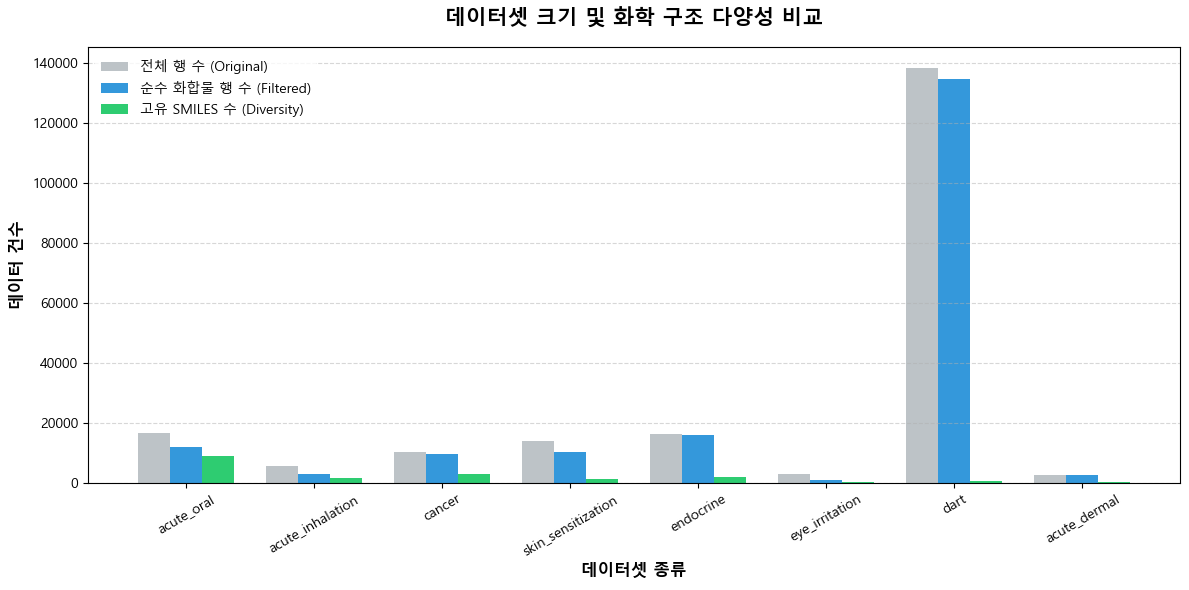

In [20]:
#5 시각화 1 - 데이터 크기 비교
plt.figure(figsize=(12, 6))
x = np.arange(len(df_stats))
width = 0.25

plt.bar(x - width, df_stats['Total Rows'], width, label='전체 행 수 (Original)', color='#bdc3c7')
plt.bar(x, df_stats['Pure Chemical Rows'], width, label='순수 화합물 행 수 (Filtered)', color='#3498db')
plt.bar(x + width, df_stats['Unique SMILES'], width, label='고유 SMILES 수 (Diversity)', color='#2ecc71')

plt.xlabel('데이터셋 종류', fontsize=12, fontweight='bold')
plt.ylabel('데이터 건수', fontsize=12, fontweight='bold')
plt.title('데이터셋 크기 및 화학 구조 다양성 비교', fontsize=15, fontweight='bold', pad=15)
plt.xticks(x, df_stats['Dataset'], rotation=30)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("plots/1_dataset_size_comparison.png", dpi=300)
plt.show()

#6 시각화 2: 타겟 및 카테고리 분포 (데이터 편향성 제거)
충분성: 단순한 Minority_Class_% 수치만 보는 것보다 시각화(Bar/Pie chart)를 통해 클래스 불균형을 직관적으로 파악할 수 있습니다 [133, 이전 대화].
이유: 독성 모델링에서 특정 클래스(예: 자극성)가 너무 적으면 모델은 단순히 "항상 0(비자극성)"이라고 예측해도 높은 정확도를 얻게 되는 오류에 빠집니다. 이를 시각적으로 확인하고 보정하는 것은 필수입니다.

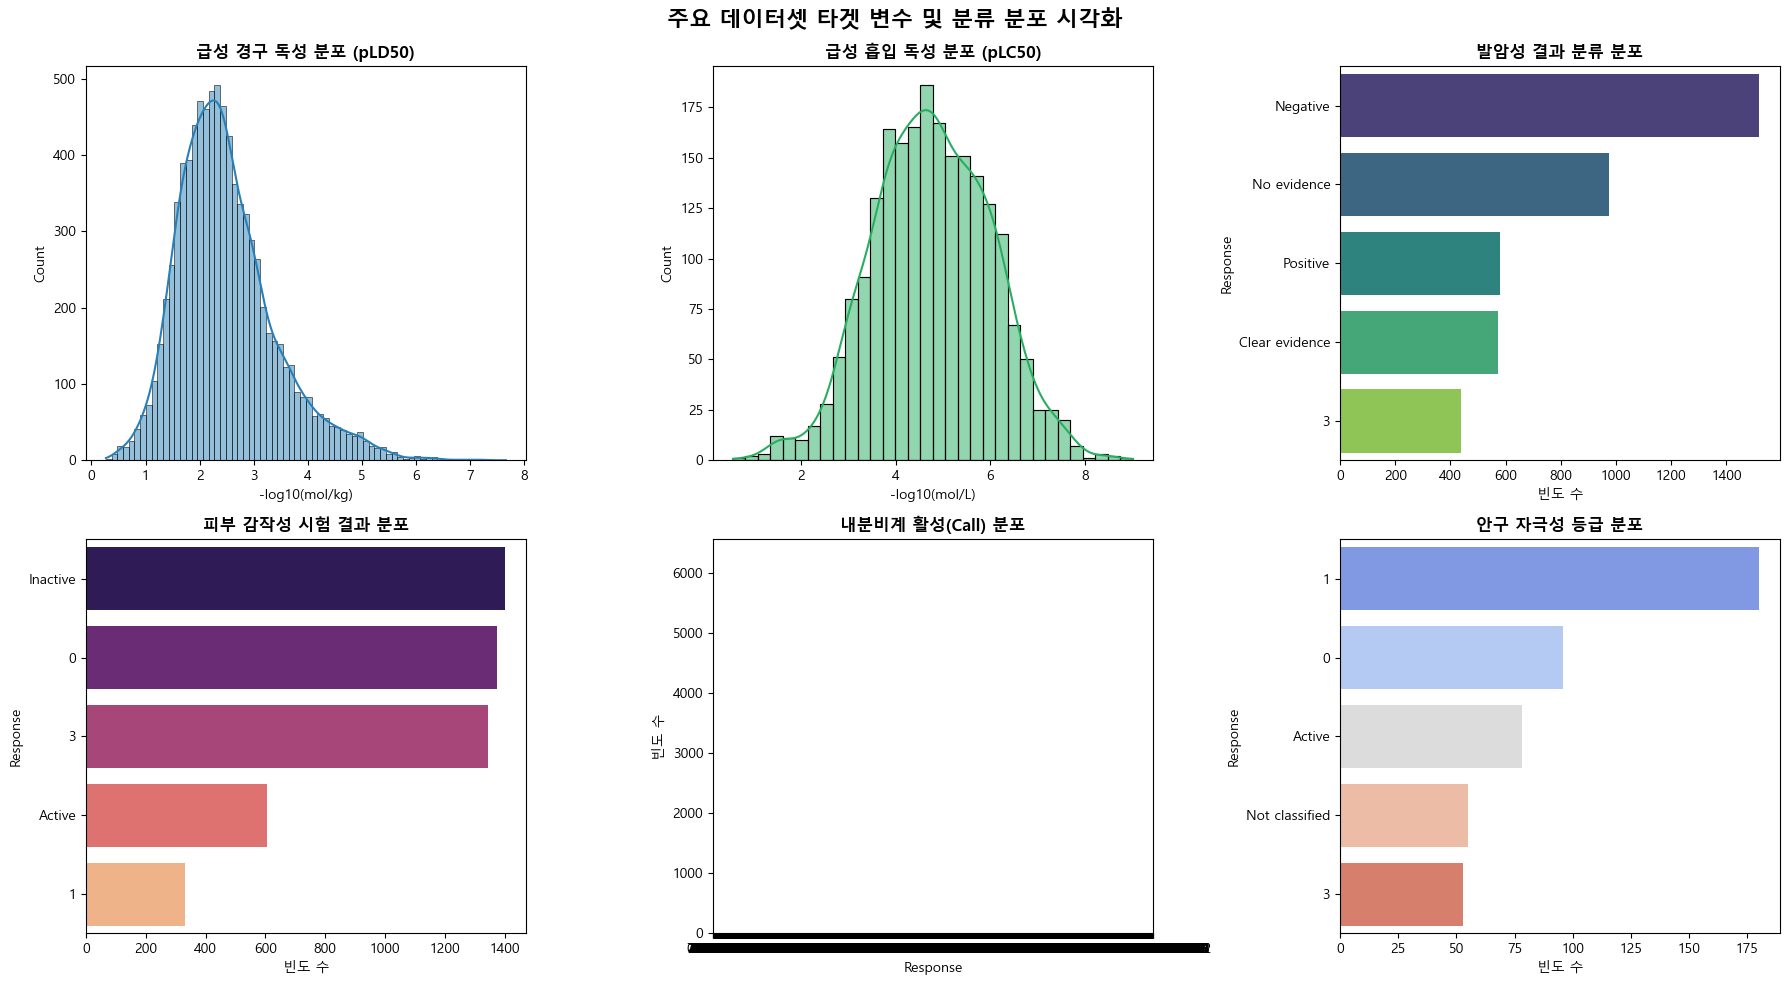

In [21]:
#6 시각화 2 - 타겟 및 카테고리 분포 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 1. Acute Oral (pLD50)
if 'acute_oral' in processed_dfs and 'pLD50' in processed_dfs['acute_oral'].columns:
    sns.histplot(processed_dfs['acute_oral']['pLD50'], kde=True, ax=axes[0], color='#2980b9')
    axes[0].set_title("급성 경구 독성 분포 (pLD50)", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("-log10(mol/kg)")
else:
    axes[0].text(0.5, 0.5, "Data Not Available", ha='center', va='center', color='red')

# 2. Acute Inhalation (pLC50)
if 'acute_inhalation' in processed_dfs and 'pLC50' in processed_dfs['acute_inhalation'].columns:
    sns.histplot(processed_dfs['acute_inhalation']['pLC50'], kde=True, ax=axes[1], color='#27ae60')
    axes[1].set_title("급성 흡입 독성 분포 (pLC50)", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("-log10(mol/L)")
else:
    axes[1].text(0.5, 0.5, "Data Not Available", ha='center', va='center')

# 3. Cancer (Carcinogenicity evidence)
if 'cancer' in processed_dfs and 'Response' in processed_dfs['cancer'].columns:
    cancer_counts = processed_dfs['cancer']['Response'].value_counts().head(5)
    sns.barplot(x=cancer_counts.values, y=cancer_counts.index, ax=axes[2], palette='viridis', hue=cancer_counts.index, legend=False)
    axes[2].set_title("발암성 결과 분류 분포", fontsize=12, fontweight='bold')
    axes[2].set_xlabel("빈도 수")
else:
    axes[2].text(0.5, 0.5, "Data Not Available", ha='center', va='center')

# 4. Skin Sensitization
if 'skin_sensitization' in processed_dfs and 'Response' in processed_dfs['skin_sensitization'].columns:
    skin_counts = processed_dfs['skin_sensitization']['Response'].value_counts().head(5)
    sns.barplot(x=skin_counts.values, y=skin_counts.index, ax=axes[3], palette='magma', hue=skin_counts.index, legend=False)
    axes[3].set_title("피부 감작성 시험 결과 분포", fontsize=12, fontweight='bold')
    axes[3].set_xlabel("빈도 수")
else:
    axes[3].text(0.5, 0.5, "Data Not Available", ha='center', va='center')

# 5. Endocrine (ER/AR call)
if 'endocrine' in processed_dfs and 'Response' in processed_dfs['endocrine'].columns:
    endo_counts = processed_dfs['endocrine']['Response'].value_counts()
    sns.barplot(x=endo_counts.index, y=endo_counts.values, ax=axes[4], palette='Set2', hue=endo_counts.index, legend=False)
    axes[4].set_title("내분비계 활성(Call) 분포", fontsize=12, fontweight='bold')
    axes[4].set_ylabel("빈도 수")
else:
    axes[4].text(0.5, 0.5, "Data Not Available", ha='center', va='center')

# 6. Eye Irritation
if 'eye_irritation' in processed_dfs and 'Response' in processed_dfs['eye_irritation'].columns:
    eye_counts = processed_dfs['eye_irritation']['Response'].dropna().value_counts().head(5)
    sns.barplot(x=eye_counts.values, y=eye_counts.index, ax=axes[5], palette='coolwarm', hue=eye_counts.index, legend=False)
    axes[5].set_title("안구 자극성 등급 분포", fontsize=12, fontweight='bold')
    axes[5].set_xlabel("빈도 수")
else:
    axes[5].text(0.5, 0.5, "Data Not Available", ha='center', va='center')

plt.suptitle("주요 데이터셋 타겟 변수 및 분류 분포 시각화", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig("plots/2_target_distributions.png", dpi=300)
plt.show()

#7 시각화 3: 화학 공간 PCA 차원 축소 (모델 적용 범위 확인)
충분성: 소스 3(skin_irritation_2Ddesc.csv)은 200개가 넘는 고차원 특성(Descriptors)을 포함하고 있습니다
. 이를 2D/3D 평면에 투영하는 PCA는 **화학 공간(Chemical Space)**을 이해하는 유일한 방법입니다.
이유: 우리가 가진 데이터가 전체 화학 물질 중 극히 일부 구조만 포함하고 있는지, 아니면 다양한 구조를 포괄하는지 확인하여 모델이 **"모르는 데이터"**에 대해 억지로 예측하는 상황을 방지합니다.

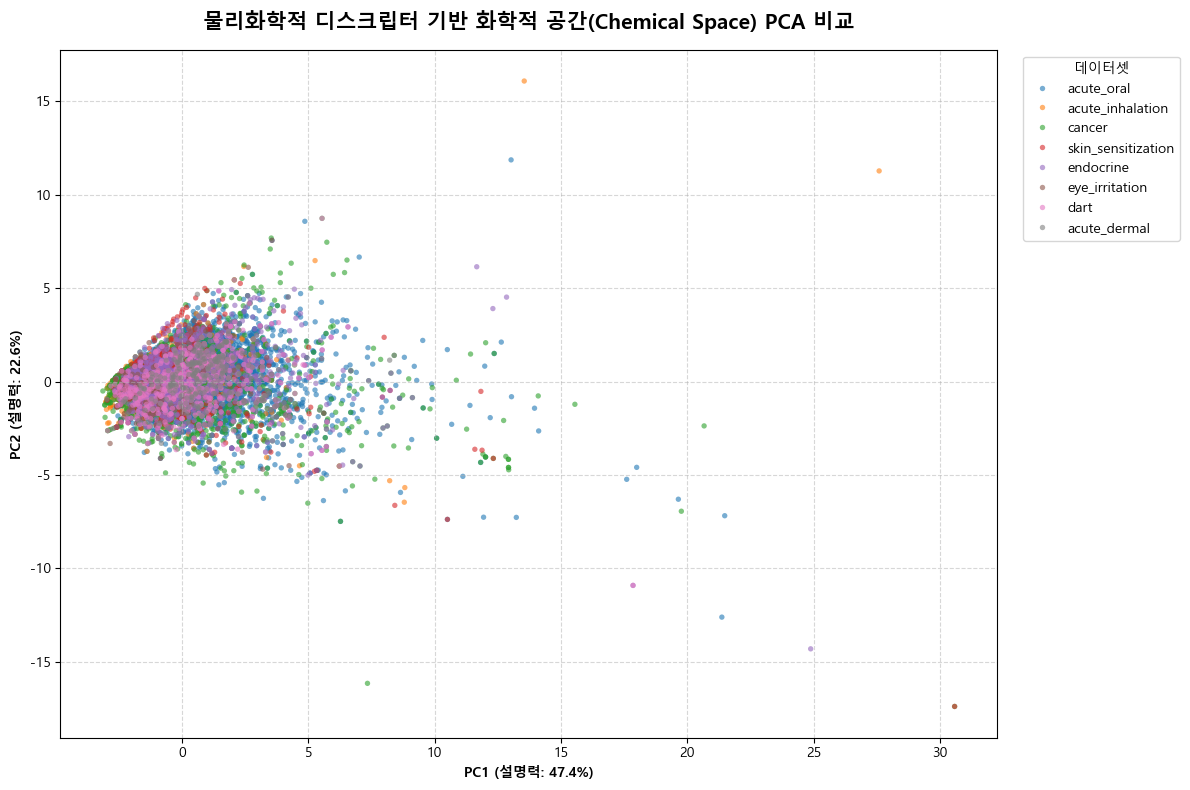

In [22]:
#7 시각화 3 - 화학 공간 PCA 차원 축소 비교
pca_data_list = []
desc_cols = ["MW", "LogP", "TPSA", "HBD", "HBA", "RotBonds", "FractionCSP3", "HeavyAtoms"]

for name, df in processed_dfs.items():
    if 'SMILES' in df.columns and len(df) > 0:
        df_unique = df.drop_duplicates(subset=['SMILES']).copy()
        df_sub = df_unique[['SMILES'] + desc_cols].copy()
        df_sub['Dataset'] = name
        pca_data_list.append(df_sub)

if len(pca_data_list) > 0:
    df_pca_all = pd.concat(pca_data_list, axis=0).reset_index(drop=True)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_pca_all[desc_cols])

    pca = PCA(n_components=2)
    coords = pca.fit_transform(X_scaled)
    df_pca_all['PC1'] = coords[:, 0]
    df_pca_all['PC2'] = coords[:, 1]

    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=df_pca_all, x='PC1', y='PC2', hue='Dataset', 
        palette='tab10', alpha=0.6, s=15, edgecolor='none'
    )
    plt.title("물리화학적 디스크립터 기반 화학적 공간(Chemical Space) PCA 비교", fontsize=15, fontweight='bold', pad=15)
    plt.xlabel(f"PC1 (설명력: {pca.explained_variance_ratio_[0]*100:.1f}%)", fontweight='bold')
    plt.ylabel(f"PC2 (설명력: {pca.explained_variance_ratio_[1]*100:.1f}%)", fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title="데이터셋", frameon=True, facecolor='white', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig("plots/3_chemical_space_pca.png", dpi=300)
    plt.show()

시각화 4: 디스크립터 간 상관관계 히트맵 (중복 정보 제거)
충분성: MaxAbsEStateIndex, MolWt, Chi 지수 등 수많은 디스크립터들 사이에는 **다중공선성(서로 강하게 연관됨)**이 존재할 가능성이 큽니다
.
이유: 상관관계가 너무 높은(예: 0.9 이상) 특성들을 그대로 두면 모델이 불필요하게 복잡해지고 과적합(Overfitting)될 위험이 있습니다. 히트맵을 통해 중복된 '노이즈'를 제거함으로써 모델을 더 가볍고 정확하게 만듭니다.

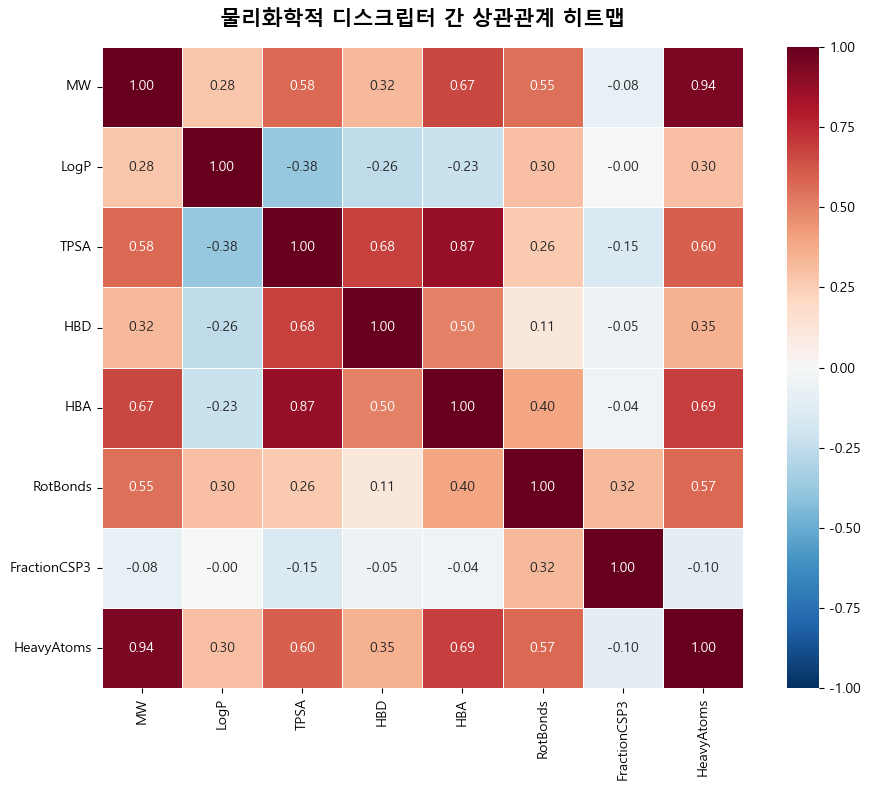

In [23]:
#8
if len(pca_data_list) > 0:
    unique_chemicals = df_pca_all.drop_duplicates(subset=['SMILES'])
    corr = unique_chemicals[desc_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5, 
        vmin=-1, vmax=1, square=True, annot_kws={"size": 10}
    )
    plt.title("물리화학적 디스크립터 간 상관관계 히트맵", fontsize=15, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig("plots/4_descriptor_correlation_heatmap.png", dpi=300)
    plt.show()